In [1]:
# IRL AutoRegressive - Full Phi
# This algorithm is intended to explore the IRL algorithm with Phi's represented differently than before.
# Previously, the phis were aggregated to have the size of 'nr' which means that the running features were integrated upto the terminal
# stage, and the terminal feature was added to the sum. In this algorithm we're trying to devide the two and have a phi vector
# of the size '2nr'. 

In [2]:
import crocoddyl
import pinocchio
from IPython.display import HTML
import mim_solvers
import numpy as np
import random
from matplotlib import animation
from matplotlib import pyplot as plt
from PointMass_utils import *
from PointMass_model import *
from scipy.optimize import minimize
from scipy.optimize import Bounds

In [3]:
nx = 4
nu = 2
T = 50
start_point = np.array([0, 0, 0, 0])
target_low = np.array([10, 0, 0, 0])
target_high = np.array([10, 10, 0, 0])
obs_act = 2
obs0 = Obstacle(10, 8, 2, obs_act, 'Obs0')
obs1 = Obstacle(8, 10, 1, obs_act, 'Obs1')
obs2 = Obstacle(8, 8, 1, obs_act, 'Obs2')
obs3 = Obstacle(10, 8, 1, obs_act, 'Obs3')
obs4 = Obstacle(8, 12, 1, obs_act, 'Obs4')
obs5 = Obstacle(10, 12, 1, obs_act, 'Obs5')
obs6 = Obstacle(7.5, 3, 1, obs_act, 'Obs6')
obs7 = Obstacle(5, 1, 1, obs_act, 'Obs7')
obs8 = Obstacle(2.5, 2, 1, obs_act, 'Obs8')
obs_set = [obs1, obs2]#, obs3, obs4, obs5, obs6, obs7, obs8]
# obs_set = [obs0]
translation_cost = XReg(nx, target_high, 'trans_high')
xreg = XReg(nx, start_point, 'XReg')
ureg = UReg(nu, None, 'UReg')

cost_set = Costs()
cost_set.add_cost(translation_cost)
cost_set.add_cost(xreg)
cost_set.add_cost(ureg)
# cost_set.add_cost(obs0)
cost_set.add_cost(obs1)
cost_set.add_cost(obs2)
# cost_set.add_cost(obs3)
# cost_set.add_cost(obs4)
# cost_set.add_cost(obs5)
# cost_set.add_cost(obs6)
# cost_set.add_cost(obs7)
# cost_set.add_cost(obs8)

nr = cost_set.nr

In [4]:
# Desired Weights
w_run_possibles = np.array([10, 1., 1., 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000])
w_term_possibles = np.array([3000, 1., 1., 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000])
w_run = w_run_possibles[:nr]
w_term = w_term_possibles[:nr]
obs_set = obs_set[:nr]
# w_des = np.hstack([w_run, w_term])
w_des = (np.hstack([w_run, w_term])/(np.max(np.hstack([w_run, w_term])))).copy()
# w_des = (np.hstack([w_run, w_term])/(np.linalg.norm(np.hstack([w_run, w_term])))).copy()

In [5]:
samples = 10
xlims = [0, 10]
ylims = [0, 10]
x0 = start_point; u0 = np.array([0.0, 0.0])
xs_init = [x0 for i in range(T+1)]; us_init = [u0 for i in range(T)]
timeStep = 5e-2
max_iter = 500
# XS_Set_optimal, US_Set_optimal = test_model_full(cost_set, obs_set, samples, xlims, ylims, T, w_des, timeStep, max_iter, with_callback = False)
# xs_optimal = XS_Set_optimal[0]
# us_optimal = US_Set_optimal[0]
xs_optimal, us_optimal, _ = get_results_from_model(cost_set, xs_init, us_init, T, w_des, timeStep, max_iter, with_callback = True)

iter     merit         cost         grad      step    ||gaps||        KKT
   1  1.00833e+02  1.00833e+02  2.92138e+01  1.0000  0.00000e+00  9.98644e+00
   2  2.61018e+00  2.61018e+00  8.15779e-02  1.0000  2.66454e-14  9.38799e-01
   3  2.52192e+00  2.52192e+00  4.27086e-01  1.0000  7.03377e-11  5.25217e-01
   4  2.21908e+00  2.21908e+00  2.45633e+00  1.0000  4.93925e-10  7.71705e-01
   5  1.68432e+00  1.68432e+00  6.07981e+00  1.0000  4.73239e-09  4.07152e-01
   6  1.02379e+00  1.02379e+00  2.14028e+00  1.0000  1.26983e-08  2.04400e-01
   7  8.88152e-01  8.88152e-01  2.34226e+00  1.0000  3.90307e-09  1.38502e-01
   8  8.27701e-01  8.27701e-01  3.10114e+00  1.0000  4.88570e-09  2.80685e-02
   9  8.21961e-01  8.21961e-01  1.09126e+00  1.0000  6.55358e-09  3.34998e-03
  10  8.21453e-01  8.21453e-01  1.22512e-01  1.0000  2.38582e-09  1.16294e-04
iter     merit         cost         grad      step    ||gaps||        KKT
 END  8.21448e-01  8.21448e-01  2.47556e-03   ----   2.63978e-10  3.9872

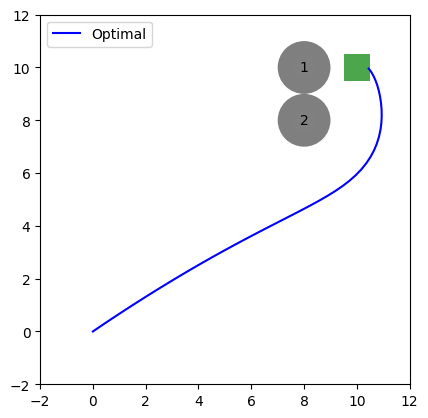

In [6]:
# HTML(animatePointMass(xs_optimal, obs_set, target_high).to_jshtml())
plot_1_traj(np.vstack(xs_optimal), obs_set, target_high, label='Optimal', linemap = 'b')

In [7]:
# Bad Running and Terminal Model
w_bad = np.zeros_like(w_des)
w_run = w_bad[:nr]
w_term = w_bad[nr:]

xs_non_optimal, us_non_optimal, sqp_non_opt = get_results_from_model(cost_set, xs_init, us_init, T, w_bad, timeStep, max_iter, with_callback = False)

In [8]:
# IRL Algorithm
def pick_highs(opt_vals, num):
    vals = np.stack(opt_vals)
    inds = sorted(range(len(vals)), key=lambda i: vals[i])[-num:][::-1]
    return inds

def pick_lows(opt_vals, num):
    vals = np.stack(opt_vals)
    inds = sorted(range(len(vals)), key=lambda i: vals[i])[:num][::-1]
    return inds

def get_cov(X):
    m = get_mean(X)
    s = np.zeros(shape=(m.shape[0],m.shape[0]))
    for x in X:
        s += (x[:,None]-m[:,None])@(x[:,None]-m[:,None]).T
    s /= len(X)
    # s += np.identity(m.shape[0])*1e-15 # Regularization
    return s

def get_mean(X):
    m = np.zeros(shape=X[0].shape)
    for x in X:
        m += x
    m /= len(X)
    return np.squeeze(m)

def get_mean_cov(phis, scale = 0.0, reg = 1e-15):
    # The new feature space will attain a covariance with 
    # our determined eigenvalues, if the features are pre-multiplied by 'cov_inv_sqrt'.
    # If scale = 0.0, the eigenvalues are all 1, if scale = 1.0, the eigenvalues won't change.
    
    new_phis = []
    phis = np.stack(phis)
    mean = get_mean(phis)
    reg_mat = np.diag(np.ones_like(mean)) * reg
    cov = get_cov(phis) + reg_mat
    if len(phis) <= len(phis[0]):
        cov_inv_sqrt = np.identity(len(phis[0]))
    else:
        EVal, EVec = np.linalg.eig(cov)
        # print(EVal)
        EV_new = np.exp(scale*np.log(EVal))
        C_p = EVec@(np.diag(np.sqrt(EVal/EV_new)))@EVec.T
        cov_inv_sqrt = np.linalg.inv(C_p)
    return mean, cov, cov_inv_sqrt

def get_phi_set(cost_set, xs, us, dt):
    phis = []
    for i, (X, U) in enumerate(zip(xs, us)):
        phis.append(cost_set.cum_feat(X, U, dt))
    return phis

def likelihood(cost_set, x_opt, u_opt, xs_set, us_set, w_run, w_term, dt, set_params):
    phis = []
    costs = []
    norm_x = [1.0]
    norm_u = [1.0]
    if set_params['use_norm']:
    # set_params['mean'] = set_params['phi_opt']
        cost_opt, phi_opt = cost_set.traj_cost_and_aug_feat_modified(x_opt, u_opt, w_run, w_term, dt, set_params['zero_mean'],set_params['cov_inv_sqrt']) 
        phis.append(phi_opt); costs.append(cost_opt)
        for x_, u_ in zip(xs_set, us_set):
            cost_nopt, phi_nopt = cost_set.traj_cost_and_aug_feat_modified(x_, u_, w_run, w_term, dt, set_params['zero_mean'],set_params['cov_inv_sqrt']) 
            phis.append(phi_nopt); costs.append(cost_nopt)
    else:
        cost_opt, phi_opt = cost_set.traj_cost_and_aug_feat(x_opt, u_opt, w_run, w_term, dt) 
        phis.append(phi_opt); costs.append(cost_opt)
        for x_, u_ in zip(xs_set, us_set):
            cost_nopt, phi_nopt = cost_set.traj_cost_and_feat(x_, u_, w_run, w_term, dt) 
            phis.append(phi_nopt); costs.append(cost_nopt)

    # print(x_opt.shape)
    # for x_, u_ in zip(xs_set, us_set):
    #     nx = 0
    #     nu = 0
    #     nx += (np.linalg.norm(x_[:-1] - x_opt[:-1])/np.linalg.norm(x_opt))*dt
    #     nx += np.linalg.norm(x_[-1] - x_opt[-1])/np.linalg.norm(x_opt)
    #     nu += (np.linalg.norm(u_[:-1] - u_opt[:-1])/np.linalg.norm(u_opt))*dt
    #     nu += np.linalg.norm(u_[-1] - u_opt[-1])/np.linalg.norm(u_opt)
        
    #     # norm_x.append(np.linalg.norm(x_ - x_opt)/np.linalg.norm(x_opt))
    #     # norm_u.append(np.linalg.norm(u_ - u_opt)/np.linalg.norm(u_opt))
    #     norm_x.append(nx)
    #     norm_u.append(nu)
    
    
    ll = 0.0
    num = 0.0
    den = 0.0
    # print(costs)
    # num = np.max([np.nextafter(0,1),np.exp(-cost_opt)])
    num = 1.0
    den = 1.0
    # if set_params['use_states']:
    #     for phi_, cost_, xn_, un_ in zip(phis[1:], costs[1:], norm_x[1:], norm_u[1:]):
    #         den += np.max([np.nextafter(0,1),(np.exp(-(cost_ - cost_opt) - xn_ - un_))])
    # else:
    for phi_, cost_ in zip(phis[1:], costs[1:]):
        den += np.max([np.nextafter(0,1),(np.exp(-(cost_ - cost_opt)))])

    
    ll = num/den
    return ll
            
def KL_D(cost_set, xs, us, w_old, w_new, dt, set_params):
    nr = cost_set.nr
    kl_array = np.zeros(len(xs))
    Px = np.zeros(len(xs))
    Qx = np.zeros(len(us))
    kl_div = 0.0
    for i, (X, U) in enumerate(zip(xs,us)):
        xs_temp = xs.copy(); xs_temp.pop(i)
        us_temp = us.copy(); us_temp.pop(i)
        Px[i] = likelihood(cost_set, X, U, xs_temp, us_temp, w_old[:nr], w_old[nr:], dt, set_params)
        Qx[i] = likelihood(cost_set, X, U, xs_temp, us_temp, w_new[:nr], w_new[nr:], dt, set_params)
    Px = Px/np.sum(Px)
    Qx = Qx/np.sum(Qx)
    kl_array = Px*np.log(Px/Qx)
    kl_div = np.sum(kl_array)
    return kl_div, kl_array


def fcn_w(x, cost_set, xs_optimal, us_optimal, xs_non_optimal_set, us_non_optimal_set, dt, set_params, Lambda = 0.001):
    nr = cost_set.nr
    output = 0
    x_run = x[:nr]; x_term = x[nr:]
    ll = likelihood(cost_set, xs_optimal, us_optimal, xs_non_optimal_set, us_non_optimal_set, x_run, x_term, dt, set_params)
    output -= np.log(ll)
    output += Lambda*np.linalg.norm(x)
    return output


In [12]:
# IRL Params
dt = timeStep
Lambda = 0.0
lb = 0; ub = np.inf
bnds = Bounds(lb, ub)
options = {'maxiter': 2, 'iprint': -1,'ftol': 1e-10 ,'gtol' : 1e-10}
tol = 1e-10
pick_best = True
pick_worst = False

w0 = w_bad
w_prev = w0
it = 0
max_set_size = 5
# it_max_IRL = max_set_size + 1
it_max_IRL = 25
it_min_IRL = max_set_size; it_min = True
it_max_sqp = 5

xs = []
us = []
xs_all = []
us_all = []
xs_non_optimal_set = []
us_non_optimal_set = []
ws = []
Fcns= []
Phis = []
KL_div = [10]; KL = 10
KL_arrs = []; KL_arrs.append(np.zeros(10))
Cost_Diffs = [1.0]
W_Diffs = [1.0]
Traj_Diffs = [1.0]
Opt_Vals = [1.0]
mean = np.zeros(cost_set.nr)
cov_inv_sqrt = np.identity(cost_set.nr)

xs_all.append(np.vstack(xs_optimal).copy()); xs_all.append(np.vstack(xs_non_optimal).copy())
us_all.append(np.vstack(us_optimal).copy()); us_all.append(np.vstack(us_non_optimal).copy())
xs_non_optimal_set.append(np.vstack(xs_non_optimal).copy()); xs.append(np.vstack(xs_non_optimal).copy())
us_non_optimal_set.append(np.vstack(us_non_optimal).copy()); us.append(np.vstack(us_non_optimal).copy())

ws.append(w_bad)

best_x = xs_non_optimal
best_u = us_non_optimal

init_choices = ['bad','optimal','previous', 'best']
stochastic = False
damping = 2
loop_tol = 1e-20
w_diff = 1
traj_diff = 1
opt_feat = cost_set.cum_aug_feat(xs_optimal,us_optimal,dt);
non_opt_feat = cost_set.cum_aug_feat(xs_non_optimal, us_non_optimal, dt);
optimality = (np.linalg.norm(opt_feat - non_opt_feat))/(np.linalg.norm(opt_feat - non_opt_feat))
prev_optimality = optimality
prev_kld = 11; KL = 10
prev_eig_norm = 1; eig_norm = 2
prev_det = 1; det = 2
d_opt = 1

# Dataset Params
set_params = {
    'use_norm': False,
    'use_states': False,
    'mean': mean,
    'zero_mean': np.zeros(2*cost_set.nr),
    'cov': None,
    'cov_inv_sqrt': cov_inv_sqrt,
    'phi_opt': opt_feat,
    'All_phis': [opt_feat, non_opt_feat],
    'Curr_set_x': [xs_optimal, xs_non_optimal],
    'Curr_set_u': [us_optimal, us_non_optimal],
    'Curr_set_phis': [opt_feat, non_opt_feat],
    'Set_phis': [non_opt_feat],
    'Set_eigs': [],
    'Set_dets': [],
    'Best_eigs': [],
    'Best_dets': []
}


# while ((prev_eig_norm-eig_norm) != 0.0 and KL > loop_tol and it < it_max_IRL) or (it_min):
while (it < it_max_IRL) or (it_min):
    sqp_non_opt = reset_weights(sqp_non_opt, w0[:nr], w0[nr:])
    prev_det = det; prev_eig_norm = eig_norm
    if len(set_params['All_phis']) > 2*(nr+3):
        set_params['use_norm'] = False
        set_params['mean'], set_params['cov'], set_params['cov_inv_sqrt'] = get_mean_cov(set_params['All_phis'], scale = 0.0, reg = 1e-12)
        set_params['Set_eigs'].append(np.linalg.eig(set_params['cov'])[0])
        set_params['Set_dets'].append(np.linalg.det(set_params['cov']))
        det = np.linalg.det(get_cov(set_params['Curr_set_phis']))
        set_params['Best_dets'].append(det)
        eig_norm = np.linalg.norm(np.linalg.eig(get_cov(set_params['Curr_set_phis']))[0])
        set_params['Best_eigs'].append(np.linalg.eig(get_cov(set_params['Curr_set_phis']))[0])
    else:
        set_params['use_norm'] = False
        set_params['mean'], set_params['cov'], set_params['cov_inv_sqrt'] = get_mean_cov(set_params['All_phis'], scale = 0.0, reg = 1e-12)
        set_params['Set_eigs'].append(np.linalg.eig(set_params['cov'])[0])
        set_params['Set_dets'].append(np.linalg.det(set_params['cov']))
        det = np.linalg.det(set_params['cov'])
        set_params['Best_dets'].append(det)
        eig_norm = np.linalg.norm(np.linalg.eig(set_params['cov'])[0])
        set_params['Best_eigs'].append(np.linalg.eig(set_params['cov'])[0])
        # det = np.linalg.det(get_cov(set_params['Curr_set_phis']))
        # set_params['Best_dets'].append(det)
        # eig_norm = np.linalg.norm(np.linalg.eig(get_cov(set_params['Curr_set_phis']))[0])
        # set_params['Best_eigs'].append(np.linalg.eig(get_cov(set_params['Curr_set_phis']))[0])
        
        
    res = minimize(fcn_w, 
                   w0, 
                   args=(cost_set, xs_optimal, us_optimal, xs_non_optimal_set, us_non_optimal_set, dt, set_params, Lambda), 
                   bounds=bnds, 
                   method='L-BFGS-B', 
                   tol = tol,
                   options=options)
    
    w_curr = res.x.copy()
    dw = normalize(np.squeeze(w_curr)) - w_prev
    w_loop = w_prev + (dw/damping) 
    w_loop = normalize(w_loop); w_run = w_loop[:nr]; w_term = w_loop[nr:]
    fcn_value = fcn_w(w_loop, cost_set, xs_optimal, us_optimal, xs, us, dt, set_params, Lambda); Fcns.append(fcn_value)
    
    # initial = random.choice(init_choices)
    initial = 'best'
    if initial == 'previous':
        # Warm-Start with previous trajectory
        xs_init = [sqp_non_opt.xs.copy()[i] for i in range(T+1)]
        us_init = [sqp_non_opt.us.copy()[i] for i in range(T)]
    elif initial == 'optimal':
        # Warm-Start with optimal trajectory
        xs_init = [xs_optimal[i] for i in range(T+1)]
        us_init = [us_optimal[i] for i in range(T)]
    elif initial == 'bad':
        # Warm-Start with zero trajectory
        xs_init = [x0 for i in range(T+1)]
        us_init = [u0 for i in range(T)]
    elif initial == 'best':
        xs_init = [best_x[i] for i in range(T+1)]
        us_init = [best_u[i] for i in range(T)]
    

    sqp_non_opt = reset_weights(sqp_non_opt, w_loop[:nr], w_loop[nr:])
    done = sqp_non_opt.solve(xs_init, us_init, it_max_sqp)
    new_traj_x = sqp_non_opt.xs.tolist().copy()
    new_traj_u = sqp_non_opt.us.tolist().copy()
    
    # Add the trajectory to the set
    xs.append(np.vstack(new_traj_x)); xs_all.append(np.vstack(new_traj_x))
    us.append(np.vstack(new_traj_u)); us_all.append(np.vstack(new_traj_u))
    ws.append(w_loop.copy())
    traj_feat = cost_set.cum_aug_feat(new_traj_x, new_traj_u, dt); set_params['All_phis'].append(traj_feat)
    optimality = (np.linalg.norm(traj_feat - opt_feat))/(np.linalg.norm(opt_feat - non_opt_feat)); Opt_Vals.append(optimality)
    w_diff = np.linalg.norm(w_loop - w_prev); W_Diffs.append(w_diff)
    traj_diff = (sqp_non_opt.cost - cost_set.traj_cost(xs_optimal, us_optimal, w_loop[:nr], w_loop[nr:], dt))**2; Traj_Diffs.append(traj_diff)
    
    if optimality < prev_optimality:
        best_x = sqp_non_opt.xs.copy()
        best_u = sqp_non_opt.us.copy()

    set_params['Curr_set_phis'] = [opt_feat]
    
    if len(xs) < max_set_size:
        xs_non_optimal_set = xs
        us_non_optimal_set = us
    else:
        if pick_best:
            inds = pick_lows(Opt_Vals,max_set_size)
            xs_non_optimal_set = [xs[i] for i in inds]
            us_non_optimal_set = [us[i] for i in inds]
        elif pick_worst:
            inds = pick_highs(Opt_Vals,max_set_size)
            xs_non_optimal_set = [xs[i] for i in inds]
            us_non_optimal_set = [us[i] for i in inds]
        else:
            xs_non_optimal_set = xs[-max_set_size:]
            us_non_optimal_set = us[-max_set_size:]
        
    if len(xs) > nr:
        if pick_best:
            inds = pick_lows(Opt_Vals,nr)
            set_params['Set_phis'] = [set_params['All_phis'][i] for i in inds]
            set_params['Curr_set_phis'] = set_merge(set_params['Curr_set_phis'], set_params['Set_phis'])
        elif pick_worst:
            inds = pick_highs(Opt_Vals,nr)
            set_params['Set_phis'] = [set_params['All_phis'][i] for i in inds]
            set_params['Curr_set_phis'] = set_merge(set_params['Curr_set_phis'], set_params['Set_phis'])
        else:
            set_params['Set_phis'] = set_params['All_phis'][-max_set_size:]
            set_params['Curr_set_phis'] = set_merge(set_params['Curr_set_phis'], set_params['Set_phis'])
    else:
        set_params['Curr_set_phis'] = set_params['All_phis']
        
    if it > 0:
        set_params['use_norm'] = False
        xs_w_opt = set_merge([xs_optimal], xs_non_optimal_set); us_w_opt = set_merge([us_optimal], us_non_optimal_set)
        # KL, KL_arr = KL_D(cost_set, xs_all, us_all, w_prev, w_loop, dt); KL_div.append(KL); KL_arrs.append(KL_arr)
        # KL, KL_arr = KL_D(cost_set, xs_non_optimal_set, us_non_optimal_set, w_prev, w_loop, dt); KL_div.append(KL); KL_arrs.append(KL_arr)
        KL, KL_arr = KL_D(cost_set, xs_w_opt, us_w_opt, w_prev, w_loop, dt, set_params); KL_div.append(KL); KL_arrs.append(KL_arr)
        KL_des, _ = KL_D(cost_set, xs_w_opt, us_w_opt, w_des, w_loop, dt, set_params)
        print('Iter: {} || KLD: {:.5f} || Desired KLD: {:.5f} || Traj Diff: {:.4f}, || Opt_Div: {:.4f}'.format(
            it+1, KL, KL_des, traj_diff, optimality
        ))
        
    d_opt = prev_optimality - optimality
    prev_optimality = optimality
    # Initial W for IRL as previous weights
    w0 = w_loop.copy()
    w_prev = w0
    it += 1
    if it > it_min_IRL:
        it_min = False

    

print(res)
w_irl = ws[-3]

/tmp/ipykernel_23364/4049722.py:100: RuntimeWarning: overflow encountered in exp
  den += np.max([np.nextafter(0,1),(np.exp(-(cost_ - cost_opt)))])
/tmp/ipykernel_23364/4049722.py:119: RuntimeWarning: divide by zero encountered in divide
  kl_array = Px*np.log(Px/Qx)


Iter: 2 || KLD: inf || Desired KLD: inf || Traj Diff: 4651.3684, || Opt_Div: 0.5464


/tmp/ipykernel_23364/4049722.py:119: RuntimeWarning: divide by zero encountered in log
  kl_array = Px*np.log(Px/Qx)
/tmp/ipykernel_23364/4049722.py:119: RuntimeWarning: invalid value encountered in multiply
  kl_array = Px*np.log(Px/Qx)


Iter: 3 || KLD: nan || Desired KLD: 37.30177 || Traj Diff: 1268.6335, || Opt_Div: 0.5006
Iter: 4 || KLD: 0.41643 || Desired KLD: 16.10763 || Traj Diff: 262.1108, || Opt_Div: 0.4568
Iter: 5 || KLD: 0.23105 || Desired KLD: 5.15700 || Traj Diff: 49.2866, || Opt_Div: 0.4195
Iter: 6 || KLD: 0.09691 || Desired KLD: 1.63298 || Traj Diff: 11.7089, || Opt_Div: 0.3878
Iter: 7 || KLD: 0.07410 || Desired KLD: 0.37907 || Traj Diff: 1.9203, || Opt_Div: 0.3475
Iter: 8 || KLD: 0.44421 || Desired KLD: 0.29616 || Traj Diff: 2.2188, || Opt_Div: 0.0864
Iter: 9 || KLD: 0.06157 || Desired KLD: 0.06067 || Traj Diff: 0.2629, || Opt_Div: 0.0449
Iter: 10 || KLD: 0.01530 || Desired KLD: 0.01112 || Traj Diff: 0.0268, || Opt_Div: 0.0504
Iter: 11 || KLD: 0.00368 || Desired KLD: 0.00190 || Traj Diff: 0.0031, || Opt_Div: 0.0946
Iter: 12 || KLD: 0.00088 || Desired KLD: 0.00027 || Traj Diff: 0.0006, || Opt_Div: 0.1269
Iter: 13 || KLD: 0.07393 || Desired KLD: 0.06648 || Traj Diff: 4.4337, || Opt_Div: 0.4149
Iter: 14 || 

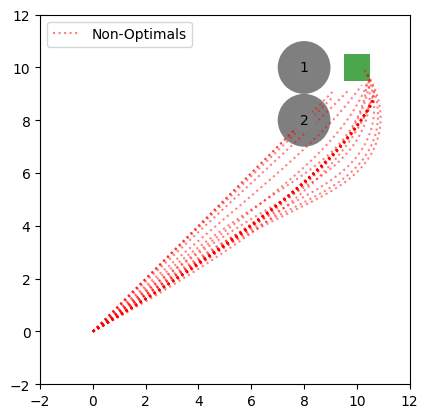

In [13]:
plot_1_set(xs, obs_set, target_high, label='Non-Optimals', linemap_traj='r:', linemap_set='r:')

processing the animation ... 
... processing done


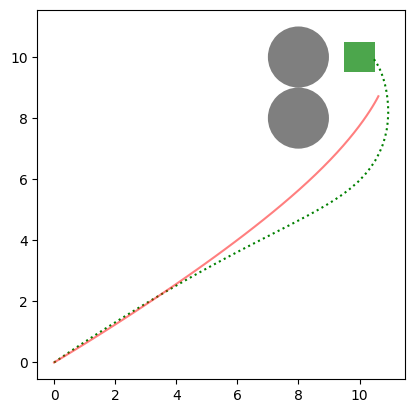

In [14]:
HTML(animateTraj(xs_optimal, xs, obs_set, target_high, max_set_size, sleep=500, animType=2).to_jshtml())